# =============================================================================
# Introdução
# =============================================================================

# Classificação de Imagens do CIFAR-10 usando uma CNN estilo VGG

Bem-vindo a este script! 👋 Nosso objetivo é treinar uma **Rede Neural Convolucional (CNN)** para classificar imagens do famoso dataset **CIFAR-10**.

## O que faremos:
1.  **Carregar e Pré-processar os Dados**: Vamos carregar o dataset CIFAR-10 e prepará-lo 
    para o treinamento. Isso inclui redimensionar as imagens e normalizar os valores de seus pixels.
2.  **Definir o Modelo CNN**: Criaremos uma CNN simples inspirada na famosa 
    arquitetura **VGG**.
3.  **Treinar o Modelo**: Treinaremos nosso modelo com os dados de treinamento, acompanhando 
    seu progresso de aprendizado ao monitorar a perda (loss).
4.  **Avaliar o Desempenho**: Finalmente, testaremos nosso modelo treinado em imagens que 
    ele nunca viu para avaliar seu desempenho. Usaremos métricas como um relatório de 
    classificação e uma matriz de confusão para avaliar sua precisão.

Vamos começar! 🚀


In [1]:
# =============================================================================
# Passo 1: Importando as Bibliotecas Necessárias
# =============================================================================
# Precisaremos de bibliotecas para manipulação de dados (numpy), construção do nosso 
# modelo (torch), carregamento de dados (torchvision) e visualização de 
# resultados (matplotlib).

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from tqdm.notebook import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchsummary import summary
import matplotlib.pyplot as plt

# =============================================================================
# Passo 2: Configuração e Pré-processamento dos Dados
# =============================================================================
Antes de carregar nossos dados, vamos definir algumas configurações importantes e 
preparar nosso pipeline de transformação de dados.

* `image_size`: Redimensionaremos todas as imagens para 32x32 pixels para garantir 
  que tenham um tamanho consistente.
* `batch_size`: Processaremos nossos dados em lotes (batches) de 64 imagens por vez. 
  Esta é uma prática comum que ajuda a treinar o modelo de forma eficiente.
* `transform`: Este é um passo crucial. Definimos uma sequência de transformações a 
  serem aplicadas em cada imagem:
    1.  `transforms.Resize()`: Redimensiona a imagem.
    2.  `transforms.ToTensor()`: Converte a imagem em um tensor do PyTorch, que é o 
        formato de dados que nosso modelo entende.
    3.  `transforms.Normalize()`: Normaliza os valores dos pixels. Isso ajuda o modelo 
        a treinar de forma mais rápida e estável. Os valores `(0.5, 0.5, 0.5)` são a 


In [2]:
# Define o tamanho da imagem, o tamanho do lote (batch) e as transformações
image_size = (32, 32)
batch_size = 64

# Define o pipeline de transformações
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normaliza para os canais R, G, B
])

# Define os nomes das classes para o dataset CIFAR-10
classes = ('aviao', 'carro', 'passaro', 'gato', 'cervo', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao')

# =============================================================================
# Passo 3: Carregando o Dataset CIFAR-10
# =============================================================================
Agora, vamos criar uma função para baixar e carregar os datasets de treinamento e teste.
O `torchvision` do PyTorch torna isso incrivelmente fácil!

O `DataLoader` é um utilitário que "embrulha" nosso dataset e fornece uma maneira fácil 
de iterar sobre ele em lotes. Vamos embaralhar (shuffle) os dados de treinamento 
para garantir que o modelo não aprenda nenhuma ordem não intencional dos dados.


In [3]:
def get_data_loaders():
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

In [4]:
train_loader, test_loader = get_data_loaders()

Files already downloaded and verified
Files already downloaded and verified


# =============================================================================
# Passo 4: Vamos Olhar Algumas Imagens!
# =============================================================================

É sempre uma boa ideia visualizar algumas imagens do nosso dataset para entender 
com o que estamos trabalhando. Vamos pegar um lote de imagens do nosso `train_loader` 
e exibir a primeira imagem junto com seu rótulo correto.

Note que as cores podem parecer um pouco estranhas. Isso ocorre porque normalizamos 
os valores dos pixels anteriormente. Precisamos "desnormalizar" as imagens antes de exibi-las.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


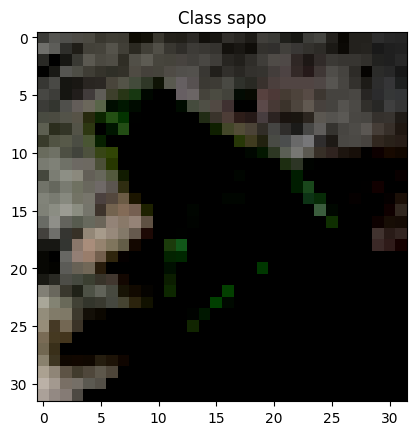

In [5]:
for data in train_loader:
    first_img = data[0][0]
    first_label = data[1][0]
    first_img = np.transpose(first_img, (1,2,0))
    plt.imshow(first_img)
    plt.title(f"Class {classes[first_label]}")
    break

# =============================================================================
# Passo 5: Definindo nossa Arquitetura CNN estilo VGG
# =============================================================================
Agora a parte emocionante! Vamos definir nossa rede neural. Este modelo é inspirado 
na **arquitetura VGG**, conhecida por sua simplicidade e eficácia. Ele consiste em 
duas partes principais:

1.  **Extrator de Características (`features`)**: Esta parte usa uma pilha de camadas 
    convolucionais (`Conv2d`) e de max pooling (`MaxPool2d`). Seu trabalho é aprender 
    a detectar padrões e características nas imagens, como bordas, texturas e formas.
    * `Conv2d`: Aplica um conjunto de filtros aprendíveis à imagem.
    * `BatchNorm2d`: Ajuda a estabilizar e acelerar o treinamento.
    * `ReLU`: Uma função de ativação que introduz não-linearidade.
    * `MaxPool2d`: Reduz a dimensão dos mapas de características, diminuindo seu tamanho 
      e tornando o modelo mais eficiente.

2.  **Classificador (`classifier`)**: Esta é uma camada simples totalmente conectada (`Linear`) 
    no final. Ela pega as características aprendidas pelas camadas convolucionais e toma 
    a decisão final sobre a qual das 10 classes a imagem pertence.

Definimos essa estrutura dentro de uma classe Python que herda de `nn.Module` do PyTorch.


In [12]:
class SimpleVGG(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleVGG, self).__init__()
        self.features = self._make_layers([64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'])
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        out = self.features(x)
        out = out.view(out.size(0), -1)
        out = self.classifier(out)
        return out

    def _make_layers(self, cfg):
        layers = []
        in_channels = 3
        for x in cfg:
            if x == 'M':
                layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
            else:
                layers += [nn.Conv2d(in_channels, x, kernel_size=3, padding=1),
                           nn.BatchNorm2d(x),
                           nn.ReLU(inplace=True)]
                in_channels = x
        layers += [nn.AvgPool2d(kernel_size=1, stride=1)]
        return nn.Sequential(*layers)

In [13]:
vgg_model = SimpleVGG()
summary(vgg_model.cuda(), (3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
       BatchNorm2d-2           [-1, 64, 32, 32]             128
              ReLU-3           [-1, 64, 32, 32]               0
         MaxPool2d-4           [-1, 64, 16, 16]               0
            Conv2d-5          [-1, 128, 16, 16]          73,856
       BatchNorm2d-6          [-1, 128, 16, 16]             256
              ReLU-7          [-1, 128, 16, 16]               0
         MaxPool2d-8            [-1, 128, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         295,168
      BatchNorm2d-10            [-1, 256, 8, 8]             512
             ReLU-11            [-1, 256, 8, 8]               0
           Conv2d-12            [-1, 256, 8, 8]         590,080
      BatchNorm2d-13            [-1, 256, 8, 8]             512
             ReLU-14            [-1, 25

# =============================================================================
# Passo 6: Treinamento do modelo
# =============================================================================
É aqui que a mágica acontece! Faremos um loop através dos nossos dados pelo número 
especificado de épocas. Em cada época, fazemos o seguinte:

1.  Pegamos um lote de imagens e rótulos do `train_loader`.
2.  Movemos os dados para a GPU (se disponível).
3.  **Passo Forward**: Alimentamos o modelo com as imagens para obter suas previsões (`outputs`).
4.  **Cálculo da Perda**: Comparamos as previsões do modelo com os rótulos verdadeiros 
    usando nossa função de perda.
5.  **Passo Backward (Retropropagação)**: Calculamos os gradientes (ou seja, o quanto 
    cada parâmetro contribuiu para o erro).
6.  **Atualização dos Pesos**: O otimizador usa esses gradientes para ajustar os pesos 
    do modelo, movendo-os na direção que reduz a perda.

Usaremos o `tqdm` para mostrar uma barra de progresso e acompanhar o andamento do treinamento.

In [14]:
epochs = 10
lr = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg_model.parameters(), lr=lr)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
vgg_model.to(device)
plot_loss = []
for epoch in range(epochs):
    running_loss = 0.0
    loop = tqdm(enumerate(train_loader), total=len(train_loader), leave=True)
    for i, data in loop:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)
    
        optimizer.zero_grad()
    
        outputs = vgg_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    
        running_loss += loss.item()
        if i % 100 == 99:
            plot_loss.append(running_loss)
            running_loss = 0.0
        
        loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
        loop.set_postfix(loss=loss.item())

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

# =============================================================================
# Passo 7: Visualizando a Perda de Treinamento
# =============================================================================
Vamos plotar a perda que registramos durante o treinamento. Uma tendência de queda 
na curva de perda é um bom sinal de que nosso modelo estava aprendendo corretamente.


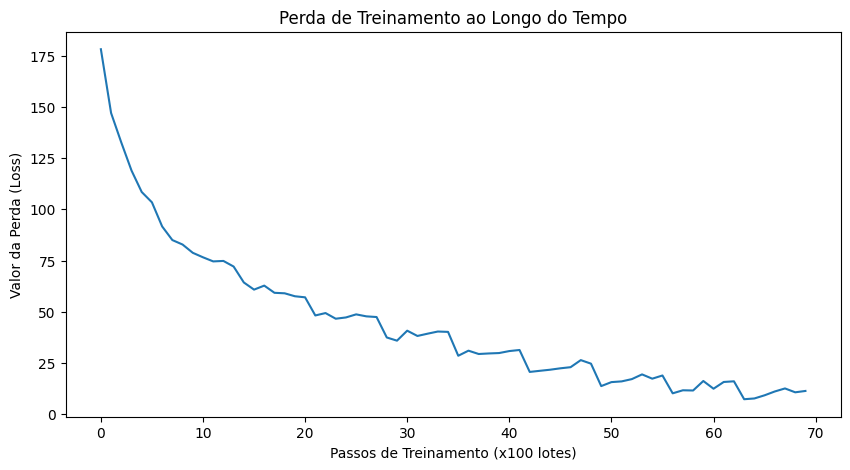

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(plot_loss)
plt.xlabel("Passos de Treinamento (x100 lotes)")
plt.ylabel("Valor da Perda (Loss)")
plt.title("Perda de Treinamento ao Longo do Tempo")
plt.show()

# =============================================================================
# Passo 8: Avaliando o Desempenho do Modelo
# =============================================================================
O treinamento acabou! Agora, vamos ver o quão bem nosso modelo se sai no **conjunto de teste**
— dados que ele nunca viu antes. Nós vamos:

1.  **Gerar Previsões**: Passar os dados de teste pelo nosso modelo para obter suas previsões.
2.  **Criar um Relatório de Classificação**: Este relatório nos mostrará precisão, recall e 
    F1-score para cada classe, nos dando uma visão detalhada do desempenho.
3.  **Exibir uma Matriz de Confusão**: Esta é uma ótima maneira de visualizar quais classes 
    o modelo está confundindo com outras. A diagonal mostra o número de previsões corretas 
    para cada classe.
4.  **Visualizar Previsões**: Vamos olhar algumas imagens de teste e ver o que o modelo 
    previu versus o rótulo verdadeiro. Previsões corretas são rotuladas em **verde**, e 
    as incorretas em **vermelho**.

In [16]:
def test():
    vgg_model.eval()
    y_pred = []
    y_true = []
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = vgg_model(images)
            _, predicted = torch.max(outputs.data, 1)
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    return y_true, y_pred

def analyze(y_true, y_pred):
    print("Classification Report:")
    print(
        "\n" + classification_report(y_true, y_pred, target_names=classes)
    )

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    visualize_predictions()

def visualize_predictions(num_images=25):
    """
    Visualiza as previsões do modelo em um lote de imagens de teste.
    """
    # Pega um lote de dados de teste
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    
    # Obtém as previsões para este lote
    images_gpu = images.to(device)
    vgg_model.eval()
    outputs = vgg_model(images_gpu)
    _, predicted = torch.max(outputs, 1)
    
    predicted = predicted.cpu()

    # Plota as imagens com seus rótulos previstos e verdadeiros
    fig = plt.figure(figsize=(15, 7))
    for idx in np.arange(num_images):
        if idx >= len(images):
            break
        ax = fig.add_subplot(
            int(np.ceil(num_images / 5)), 5, idx + 1, xticks=[], yticks=[]
        )
        # Desnormaliza para exibição
        img = images[idx] / 2 + 0.5
        plt.imshow(np.transpose(img, (1, 2, 0)))
        
        pred_label = classes[predicted[idx].item()]
        true_label = classes[labels[idx].item()]
        
        # Define a cor do título como verde para previsões corretas, vermelho para incorretas
        title_color = "green" if pred_label == true_label else "red"
        
        ax.set_title(
            f"Prev: {pred_label}\n(Real: {true_label})",
            color=title_color,
        )
    plt.tight_layout()
    plt.show()



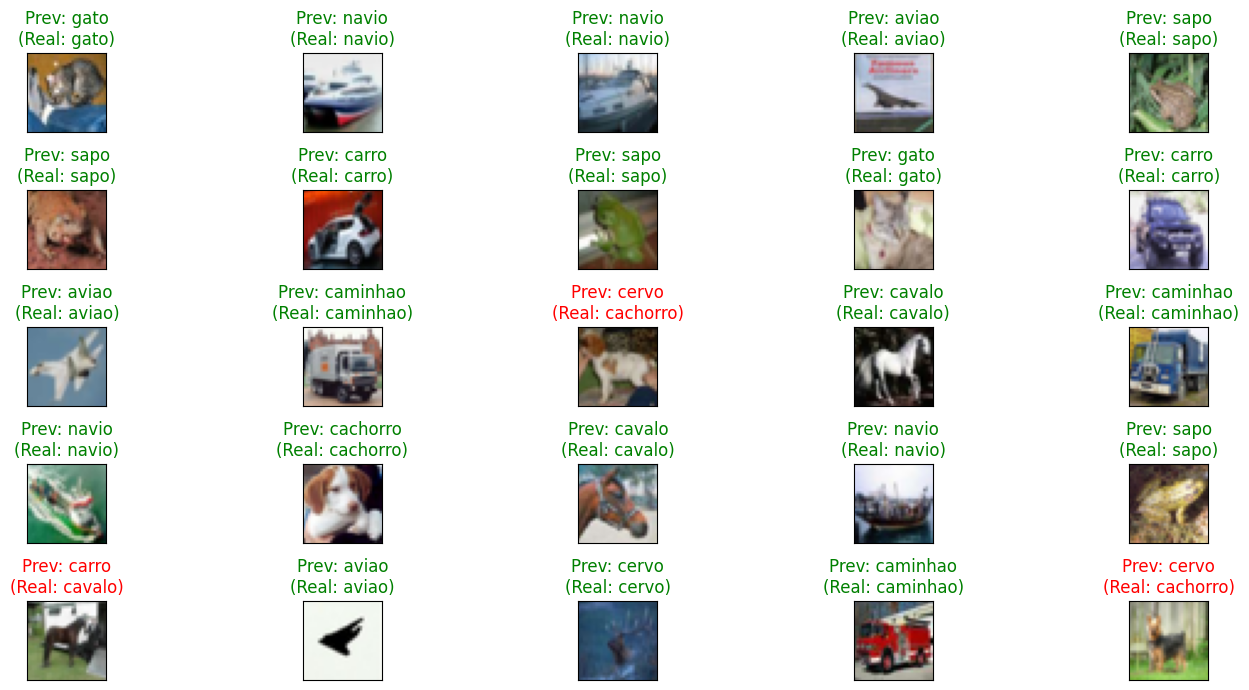

In [17]:
visualize_predictions()